# Portfolio Optimization Analysis

**Objectives**
This project implements a comprehensive portfolio optimization system using CVXPY, evolving from Markowitz optimization into a complete system that allows for the inclusion of sector and position constraints, as well as covariance matrix regularization.

## 1) Mathematical Foundation
In the basic Markowitz optimization, given:
- a returns vector $\mu \in \mathbb{R}^n$
- a covariance matrix $\Sigma$

Is possible to find the portfolio that minimize the variance, solving the follow minimization problem:
$$\min_w w \Sigma w^T$$
S.t:
- $1^T w = 1$
- $w >= 0$


## Add a target return
However all investors are different, maybe someone requires an higher return with respect to others and so on. So we can add a new constraints in the minimization problem, that regard the expected returns:
$$\min_w w \Sigma w^T$$
S.t:
- $1^T w = 1$
- $w >= 0$
- $w^T \mu = \mu_{\text{target}}$




## The efficient frontier through a risk aversion parameter
Another way to compute the optimal portfolio, without specify the target returns, which can be to higher for the asset that we choose, is to use a parameter $\lambda$ that represents the risk aversion. The problem is:

$$\max_w \mu^T w - \lambda \cdot w^T \Sigma w$$
S.t:
- $1^Tw = 1$
- $w \geq 0$

Where $\lambda \geq 0$ is the risk aversion parameter:
- $\lambda = 0$ (Maximize return, ignore the risk)
- $\lambda \to \infty$ (Minimize the variance, ignore the return)

In [1]:
# !pip install pandas, numpy, matplotlib, seaborn, yfinance, cvxpy
# install requirments

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['legend.labelcolor'] = 'white'
plt.rcParams['legend.edgecolor'] = 'white'

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

## 2) Data Acquisition 

In [3]:
def get_data(tickers : list, start_date: datetime, end_date: datetime) -> pd.DataFrame: 
    """
    Download data from yfinance.

    return : 
        daily returns for each asset
    """
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
    returns = np.log(data / data.shift(1)).dropna()
    return returns


end = datetime.now()
start = end - timedelta(days=365 * 5)

ASSETS = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Disc',
    'XLP': 'Consumer Staples',
    'XLE': 'Energy',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLU': 'Utilities',
    'XLRE': 'Real Estate',
}

ticker = list(ASSETS.keys())
returns = get_data(ticker, start, end)
returns.columns = ASSETS.values()
returns.tail(10)

[*********************100%***********************]  10 of 10 completed


,Technology,Financials,Healthcare,Consumer Disc,Consumer Staples,Energy,Industrials,Materials,Utilities,Real Estate
Date,,,,,,,,,,
2026-09-23,-0.0050,0.0095,-0.0048,-0.0010,-0.0047,-0.0036,-0.0157,-0.0194,-0.0064,-0.0151
2026-09-24,-0.0120,0.0037,-0.0002,-0.0075,-0.0032,-0.0089,-0.0046,-0.0099,0.0063,-0.0030
2026-09-25,0.0024,-0.0090,0.0057,0.0094,0.0080,0.0044,-0.0022,0.0038,0.0049,0.0022
2026-09-28,-0.0066,0.0010,-0.0119,-0.0097,-0.0089,0.0027,-0.0051,-0.0066,0.0033,-0.0142
2026-09-29,-0.0075,-0.0091,-0.0033,0.0021,-0.0002,-0.0052,-0.0002,0.0117,-0.0031,0.0014
2026-09-30,-0.0082,-0.0007,-0.0114,-0.0128,0.0064,-0.0154,-0.0105,-0.0068,-0.0136,-0.0028
2026-10-01,-0.0033,0.0193,0.0011,0.0099,0.0105,-0.0034,-0.0056,0.0061,-0.0133,-0.0003
2026-10-02,0.0066,0.0019,0.0006,0.0077,0.0101,0.0025,0.0032,0.0038,-0.0001,0.0112
2026-10-05,0.0130,0.0100,0.0073,0.0009,0.0056,0.0063,-0.0034,0.0035,0.0071,0.0034


In [4]:
def estimate_parameters(returns : pd.DataFrame, annualized_factor : int) -> tuple:
    """
    Estimate expected return and covariance matrix from data
    """
    mu = returns.mean(axis=0) * annualized_factor
    Sigma = returns.cov() * annualized_factor
    return mu, Sigma

mu, Sigma = estimate_parameters(returns, annualized_factor=252)

stats_df = pd.DataFrame({
    'Expected return (%)' : mu*100,
    'Volatility (%)' : np.sqrt(np.diag(Sigma)) * 100,
    'Sharpe Ratio' : mu / np.sqrt(np.diag(Sigma)),
}, index = ASSETS.values())

print("Assets Statistics")
print("--"*35)
print(stats_df.to_string(float_format=lambda x: f"{x:.3f}"))

Assets Statistics
----------------------------------------------------------------------
                  Expected return (%)  Volatility (%)  Sharpe Ratio
Technology                      6.086          19.084         0.319
Financials                     19.895          25.539         0.779
Healthcare                      8.272          18.318         0.452
Consumer Disc                  12.186          17.588         0.693
Consumer Staples               20.425          25.896         0.789
Energy                          5.786          13.714         0.422
Industrials                     1.768          19.150         0.092
Materials                       7.850          17.441         0.450
Utilities                       7.168          15.173         0.472
Real Estate                     4.902          24.129         0.203


## 3) Covariance Matrix Regularization

For improving numerical stability we apply Tikhonov regularization on the covariance matrix:

$$\Sigma_{\text{reg}} = \Sigma + \varepsilon I$$
This raises all eigenvalue by $\varepsilon$.

In [5]:
def regularize_cov_matrix(Sigma : np.ndarray, epsilon : float) -> np.ndarray:
    """
    Apply tikhonov regularization on the covariance matrix
    """

    n = Sigma.shape[0]
    I = np.eye(n)
    return Sigma + epsilon * I


def analyze_epsilon(Sigma : np.ndarray, name : str = "") -> dict:
    eigvalues = np.linalg.eigvalsh(Sigma)
    max_eig = np.max(eigvalues)
    min_eig = np.min(eigvalues)
    conditional_number = max_eig / min_eig

    return {
        'name' : name,
        'max eigenvalue': max_eig,
        'min eigenvalue' : min_eig,
        'conditional number' : conditional_number
    }

epsilons = np.linspace(0, 1e-2, 10)

results = []
for eps in epsilons:
    Sigma_reg = regularize_cov_matrix(Sigma, eps)
    result = analyze_epsilon(Sigma_reg, f"eps={eps:.4f}")
    results.append(result)

results = pd.DataFrame(results)
print(results.to_string(float_format= lambda x: f"{x:.4f}"))

         name  max eigenvalue  min eigenvalue  conditional number
0  eps=0.0000          0.2259          0.0047             48.2237
1  eps=0.0011          0.2271          0.0058             39.1715
2  eps=0.0022          0.2282          0.0069             33.0314
3  eps=0.0033          0.2293          0.0080             28.5930
4  eps=0.0044          0.2304          0.0091             25.2349
5  eps=0.0056          0.2315          0.0102             22.6054
6  eps=0.0067          0.2326          0.0114             20.4907
7  eps=0.0078          0.2337          0.0125             18.7531
8  eps=0.0089          0.2348          0.0136             17.2999
9  eps=0.0100          0.2359          0.0147             16.0667


we'll use epsilon=0.0089 for the analysis

## 4) Core Portfolio Optimization

In [6]:
class PortfolioOptimization:

    def __init__(self, mu: np.ndarray, Sigma_reg: np.ndarray):
        self.mu = mu
        self.Sigma_reg = Sigma_reg

        self.weights = None

    def solve_min_variance(self) -> tuple:
        """
        Solve min variance portfolio:
            min_w w @ Sigma @ w.T
            subject to:
             - 1.T w = 1
             - w >= 0
        """
        n = self.Sigma_reg.shape[0]
        self.weights = cp.Variable(n)

        objective = cp.Minimize(cp.quad_form(self.weights, self.Sigma_reg))
        constraints = [cp.sum(self.weights) == 1, self.weights >= 0]

        problem = cp.Problem(objective=objective, constraints=constraints)
        problem.solve()

        return self.weights.value, problem.value

    def solve_target_return(self, target_return : float) -> tuple:
        """
        Solve min variance portfolio:
            min_w w.T @ Sigma @ w
            subject to:
             - 1.T @ w = 1
             - w >= 0
             - w.T @ mu >= mu_target
        """
        n = self.Sigma_reg.shape[0]
        self.weights = cp.Variable(n)

        objective = cp.Minimize(cp.quad_form(self.weights, self.Sigma_reg))
        constraints = [cp.sum(self.weights) == 1, self.weights >= 0, self.weights @ self.mu >= target_return]

        problem = cp.Problem(objective, constraints)
        problem.solve()

        if problem.status != cp.OPTIMAL:
            return -1, -1

        return self.weights.value, problem.value

    def solve_risk_aversion(self, risk_adversion : float) -> tuple:
        """
        Solve the risk-aversion portfolio problem.
            
            maximize    mu.T @ w - lambda * w.T @ Sigma @ w
            subject to  1.T @ w = 1
                        w >= 0
        """
        n = self.Sigma_reg.shape[0]
        self.weights = cp.Variable(n)

        objective = cp.Maximize(self.weights @ self.mu - risk_adversion * cp.quad_form(self.weights, self.Sigma_reg))
        constraints = [cp.sum(self.weights) == 1, self.weights >= 0]

        problem = cp.Problem(objective, constraints)
        problem.solve()

        return self.weights.value, problem.value
    

In [7]:
Sigma_reg = regularize_cov_matrix(Sigma, epsilon=0.0089)
optimization = PortfolioOptimization(mu, Sigma_reg)

# min variance portfolio
min_variance_weights, portfolio_variance = optimization.solve_min_variance()
df_minvar_weights = pd.DataFrame(min_variance_weights, index=ASSETS.values(), columns = ['Weights'])

print("Mean Variance Portfolio")
print("--"*30)
print(df_minvar_weights.to_string(float_format=lambda x : f"{x:.4f}"))
print(f"\nPortfolio Volatility: {np.sqrt(portfolio_variance) * 100:.2f}%")

Mean Variance Portfolio
------------------------------------------------------------
                  Weights
Technology         0.0000
Financials         0.0982
Healthcare         0.0410
Consumer Disc      0.0688
Consumer Staples   0.0590
Energy             0.3493
Industrials       -0.0000
Materials          0.1574
Utilities          0.2264
Real Estate        0.0000

Portfolio Volatility: 13.14%


In [8]:
# target return portfolio
target_return = 0.12
target_return_weights, portfolio_variance_tr = optimization.solve_target_return(target_return)
df_tr_weights = pd.DataFrame(target_return_weights, index=ASSETS.values(), columns = ['Weights'])

print(f"\nTarget Return Portfolio, target return = {target_return*100}%")
print("--"*30)
print(df_tr_weights.to_string(float_format=lambda x : f"{x:.4f}"))
print(f"\nPortfolio Volatility: {np.sqrt(portfolio_variance_tr) * 100:.2f}%")


Target Return Portfolio, target return = 12.0%
------------------------------------------------------------
                  Weights
Technology         0.0000
Financials         0.1989
Healthcare         0.0000
Consumer Disc      0.0533
Consumer Staples   0.1747
Energy             0.2707
Industrials        0.0000
Materials          0.1343
Utilities          0.1681
Real Estate        0.0000

Portfolio Volatility: 13.77%


In [9]:
risk_aversion = 1.5 
ra_weights, max_utility = optimization.solve_risk_aversion(risk_adversion=risk_aversion)

if ra_weights is not None:
    df_ra_weights = pd.DataFrame(ra_weights, index=ASSETS.values(), columns=['Weights'])

    port_variance = ra_weights @ Sigma_reg @ ra_weights
    port_volatility = np.sqrt(port_variance)
    port_return = ra_weights @ mu

    print(f"\nRisk Aversion Portfolio (lambda = {risk_aversion})")
    print("--" * 30)
    print(df_ra_weights.to_string(float_format=lambda x: f"{x:.4f}"))
    print(f"\nExpected Return:   {port_return * 100:.2f}%")
    print(f"Portfolio Volatility: {port_volatility * 100:.2f}%")
    print(f"Max Utility Value:   {max_utility:.4f}")
else:
    print("Ottimizzazione fallita.")



Risk Aversion Portfolio (lambda = 1.5)
------------------------------------------------------------
                  Weights
Technology        -0.0000
Financials         0.4928
Healthcare         0.0000
Consumer Disc     -0.0000
Consumer Staples   0.5072
Energy             0.0000
Industrials        0.0000
Materials         -0.0000
Utilities          0.0000
Real Estate        0.0000

Expected Return:   20.16%
Portfolio Volatility: 21.33%
Max Utility Value:   0.1334


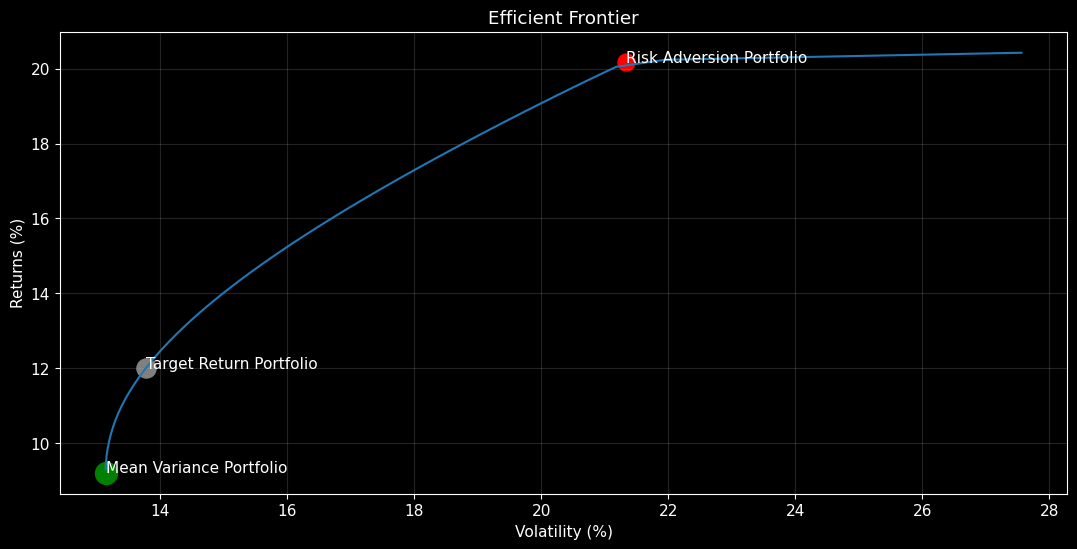

In [10]:
def build_efficient_frontier(mu, Sigma, n_points=50):
    mu_arr = mu.values 
    
    min_ret = np.min(mu_arr)
    max_ret = np.max(mu_arr)

    targets = np.linspace(min_ret, max_ret, n_points)
    n = len(mu_arr)
    w = cp.Variable(n)

    returns = []
    volatilities = []
    all_weights = []

    for mu_target in targets:
        objective = cp.Minimize(cp.quad_form(w, Sigma))
        
        constraints = [cp.sum(w) == 1, w >= 0, mu_arr @ w == mu_target]
        
        problem = cp.Problem(objective, constraints)
        problem.solve() 

        if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE] and problem.value is not None:
            w_opt = w.value
            var_opt = np.maximum(0, problem.value)
            vol_opt = np.sqrt(var_opt)

            actual_return = mu_arr @ w_opt

            returns.append(actual_return)
            volatilities.append(vol_opt)
            all_weights.append(w_opt)

    return np.array(returns), np.array(volatilities), np.array(all_weights)


# Esecuzione
returns_frontiera, vol_frontiera, all_weights = build_efficient_frontier(mu, Sigma_reg, n_points=100)

df_frontiera = pd.DataFrame({
    'Returns' : returns_frontiera * 100,
    'Volatility' : vol_frontiera * 100
})

# sort by returns
df_frontiera = df_frontiera.sort_values(by='Returns')
min_vol_idx = df_frontiera['Volatility'].idxmin()
df_frontiera = df_frontiera.loc[min_vol_idx :].copy()

plt.plot(df_frontiera['Volatility'], df_frontiera['Returns'])

# min vol
mv_return = (min_variance_weights @ mu )* 100
mv_vol = np.sqrt(portfolio_variance) * 100

plt.scatter(mv_vol, mv_return, color='green', s=250)
plt.annotate('Mean Variance Portfolio', xy=(mv_vol, mv_return), color='white')

# target return portfolio
tr_returns = (target_return_weights @ mu) * 100
tr_vol = np.sqrt(portfolio_variance_tr) * 100

plt.scatter(tr_vol, tr_returns, color='grey', s=190)
plt.annotate('Target Return Portfolio', xy=(tr_vol, tr_returns), color='white')

# risk adversion portfolio
ra_returns = (ra_weights @ mu) * 100
ra_vol = np.sqrt(port_variance) * 100

plt.scatter(ra_vol, ra_returns, color='red', s=150)
plt.annotate('Risk Adversion Portfolio', xy=(ra_vol, ra_returns), color='white')

# assets in the efficient forntier



plt.title("Efficient Frontier")
plt.xlabel('Volatility (%)')
plt.ylabel('Returns (%)')
plt.grid(True, alpha=.2)
plt.show()

## 5) Optimization with constraints

In practice, some portfolios meet other limits beyond long-only and weight. Some of them are:
- Position limit: $w_i \leq w_{max}$
- Sector limit: $\sum_{i \in \text{sector}} w_i \leq s_{\text{max}}$
- Turnover limit: $\sum_i |w_i - w_i^{\text{current}}| \leq \alpha$

In [11]:
def optimize_portfolio(
    mu: np.ndarray,
    Sigma: np.ndarray,
    risk_aversion: float,
    w_min: float,
    w_max: float,
    max_sector_weight : np.ndarray = None,
    w_current: np.ndarray = None,
    turnover_max: float = None,
    regularization: float = 1e-4
) -> dict:
    """
    Solve a complete portfolio optimization with real constraints.

    maximize    mu.T @ w - lambda * w.T @ Sigma @ w
        subject to
            - 1.T @ w = 1
            - w >= w_min
            - w <= w_max
            - w_secotr <= w_max_sector
            - Sum_i |w_i - w_current| <= alpha

    """
    
    mu_arr = mu.values
    n = Sigma.shape[0]

    # Covariance Matrix Regularization
    if regularization is not None:
        Sigma_reg = Sigma + regularization * np.eye(n)

    
    w = cp.Variable(n)
    objective = cp.Maximize(w.T @ mu_arr - risk_aversion * cp.quad_form(w, Sigma_reg))

    # constraints
    constraints = [cp.sum(w) == 1, w >= w_min, w <= w_max]

    # turnover constraints
    if w_current is not None and turnover_max is not None:
        constraints.append(cp.norm(w - w_current, 1) <= turnover_max)

    # sector constraints
    if max_sector_weight is not None:
        constraints.append(w <= max_sector_weight)
    
    problem = cp.Problem(objective, constraints)
    problem.solve()

    if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
        raise ValueError(f"L'ottimizzazione non è riuscita. Stato: {problem.status}")

    
    w_opt = w.value

    portfolio_return = float(w_opt @ mu_arr)
    portfolio_vol = float(np.sqrt(w_opt.T @ Sigma @ w_opt))
    sharpe = portfolio_return / portfolio_vol if portfolio_vol > 0 else 0.0

    turnover = (float(np.sum(np.abs(w_opt - w_current))) if w_current is not None else None)

    return {
        'Optimal Weights': w_opt,
        'Returns': portfolio_return,
        'Volatility': portfolio_vol,
        'Sharpe': sharpe,
        'Turnover': turnover,
    }


# --- Execution ---

# past weights
w_current = np.array([0.20, 0.15, 0.10, 0.10, 0.10, 0.05, 0.10, 0.05, 0.10, 0.05])

# set sector constraints
sector_limits = {
    'Technology': 0.25,  
    'Financials': 0.20,  
    'Energy': 0.10,  
}
default_max = 0.35
max_sector_weights = np.array([sector_limits.get(col, default_max) for col in returns.columns])

optimal = optimize_portfolio(mu, Sigma, risk_aversion=3, w_min=0.05, w_max=0.35, max_sector_weight=max_sector_weights, w_current=w_current, turnover_max= 0.30, regularization=1e-4)


asset_names = returns.columns
df_weights = pd.DataFrame({
        'Past Weights (%)': w_current * 100,
        'Optimal Weights (%)': optimal['Optimal Weights'] * 100,
        'Change (%)': (optimal['Optimal Weights'] - w_current) * 100,
    }, index=asset_names)

print("=== PORTFOLIO ALLOCATION ===")
print(df_weights.round(2).to_string())

print("\n=== PORTFOLIO METRICS ===")
print(f"Expected Return:   {optimal['Returns'] * 100:.2f}%")
print(f"Volatility:        {optimal['Volatility'] * 100:.2f}%")
print(f"Sharpe Ratio:      {optimal['Sharpe']:.2f}")
if optimal['Turnover'] is not None:
    print(f"Effective Turnover: {optimal['Turnover'] * 100:.2f}%")


=== PORTFOLIO ALLOCATION ===
                  Past Weights (%)  Optimal Weights (%)  Change (%)
Technology                    20.0                 10.0       -10.0
Financials                    15.0                 20.0         5.0
Healthcare                    10.0                 10.0        -0.0
Consumer Disc                 10.0                 10.0        -0.0
Consumer Staples              10.0                 20.0        10.0
Energy                         5.0                  5.0        -0.0
Industrials                   10.0                  5.0        -5.0
Materials                      5.0                  5.0        -0.0
Utilities                     10.0                 10.0        -0.0
Real Estate                    5.0                  5.0        -0.0

=== PORTFOLIO METRICS ===
Expected Return:   12.45%
Volatility:        15.49%
Sharpe Ratio:      0.80
Effective Turnover: 30.00%


# 6) Data perturbations

=== Comparison of weights stability over time ===
                  Std Uncostraints (%)  Std with Constraints (%)  Reduction of Instability (%)
Technology                        0.00                      3.47                   -3.7980e+22
Financials                       10.48                      1.95                    8.1370e+01
Healthcare                        2.07                      1.95                    6.0100e+00
Consumer Disc                    19.19                      3.65                    8.0950e+01
Consumer Staples                 12.78                      4.58                    6.4130e+01
Energy                           15.32                      1.64                    8.9320e+01
Industrials                       0.00                      2.23                   -2.1516e+22
Materials                        11.82                      2.90                    7.5440e+01
Utilities                        12.53                      1.95                    8.4450e+01


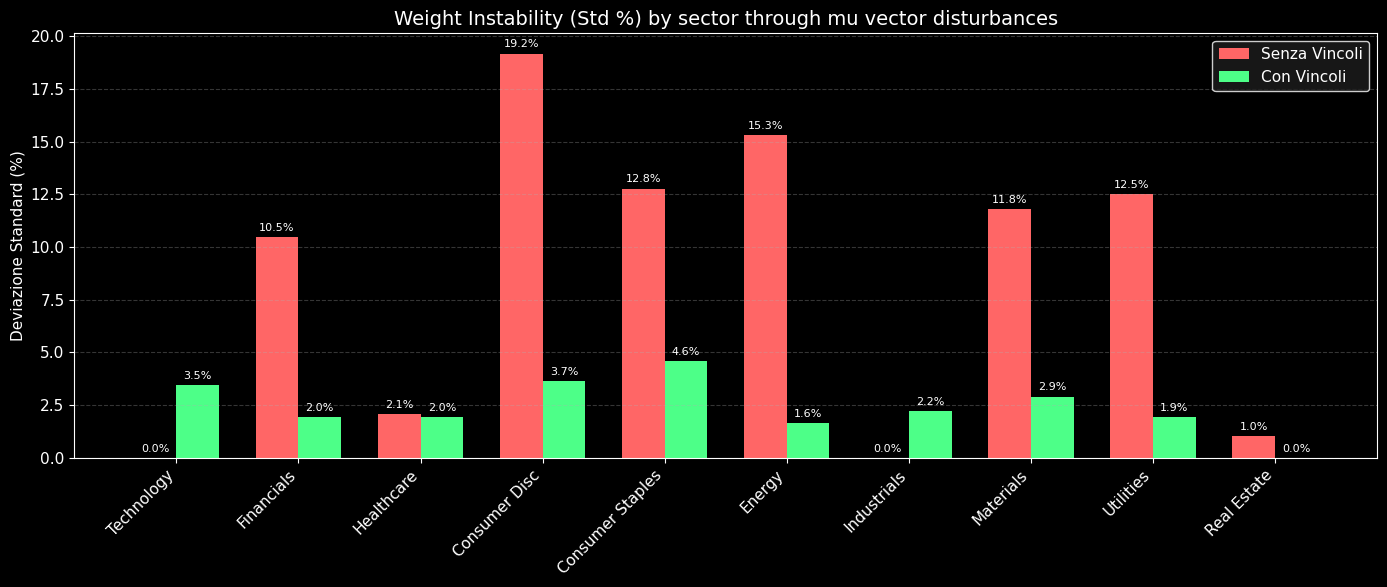

In [ ]:
np.random.seed(42)
true_mu = mu
true_Sigma = Sigma

noise = 0.03
n_simulation = 100

# generiamo il vettore perturbato
weights_unconstrained = []
weights_constrained = []
for sim in range(n_simulation):
    mu_noise = true_mu + np.random.normal(0, noise, size=(len(returns.columns)))

    # portafoglio senza limiti
    res_unconst = optimize_portfolio(mu_noise, Sigma, risk_aversion=3, w_min=0.0, w_max=1.0)

    # portafoglio con limiti
    res_const = optimize_portfolio(mu_noise, Sigma, risk_aversion=3, w_min=0.05, w_max=0.35, max_sector_weight=max_sector_weights, w_current=w_current, turnover_max=0.30, regularization=1e-4)

    if res_unconst is not None and res_const is not None:
        weights_constrained.append(res_const['Optimal Weights'])
        weights_unconstrained.append(res_unconst['Optimal Weights'])

weights_unconstrained = pd.DataFrame(weights_unconstrained, columns=returns.columns)
weights_constrained = pd.DataFrame(weights_constrained, columns=returns.columns)

# compute std for each sector
weights_std_un = weights_unconstrained.std(axis=0) * 100
weights_std_con = weights_constrained.std(axis=0) * 100

df_stability = pd.DataFrame({
    'Std Uncostraints (%)' : weights_std_un,
    'Std with Constraints (%)' : weights_std_con,
    'Reduction of Instability (%)' : ((weights_std_un - weights_std_con) / weights_std_un) * 100
})

print("=== Comparison of weights stability over time ===")
print(df_stability.round(2).to_string())


# plot
settori = returns.columns
x = np.arange(len(settori))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))


rects1 = ax.bar(x - w / 2, weights_std_un, w, label="Senza Vincoli", color="#ff6666")
rects2 = ax.bar(x + w / 2, weights_std_con, w, label="Con Vincoli", color="#4dff88")


ax.set_title("Weight Instability (Std %) by sector through mu vector disturbances", fontsize=14, color="white")
ax.set_ylabel("Deviazione Standard (%)", color="white")
ax.set_xticks(x)
ax.set_xticklabels(settori, rotation=45, ha="right", color="white")
ax.tick_params(colors="white")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")

ax.legend(facecolor="#1e1e1e", edgecolor="white", labelcolor="white")
ax.bar_label(rects1, fmt="%.1f%%", padding=3, color="white", fontsize=8)
ax.bar_label(rects2, fmt="%.1f%%", padding=3, color="white", fontsize=8)

plt.tight_layout()
plt.show()


## 7) Cost Analysis

In [33]:
def analyze_cost(mu : np.ndarray, Sigma : np.ndarray, max_weights : list) -> dict:

    results = []
    for max_w in max_weights:
        res = optimize_portfolio(mu=mu, Sigma=Sigma, risk_aversion=1.5, w_min=0, w_max=max_w, regularization=0.0001)
        results.append({
            'Max weight' : max_w * 100,
            'Returns' : res['Returns'],
            'Volatility' : res['Volatility'],
            'Sharpe' : res['Sharpe']
        })
    return results

max_weights = np.linspace(0.15, 0.60, 10)
results = analyze_cost(mu, Sigma, max_weights)
results = pd.DataFrame(results)

unconstraint_sharpe = results['Sharpe'].iloc[-1]
results['Sharpe Cost (%)'] = (unconstraint_sharpe - results['Sharpe']) / unconstraint_sharpe * 100

print(results.to_string(index=False, float_format= lambda x : f"{x:.3f}"))

 Max weight  Returns  Volatility  Sharpe  Sharpe Cost (%)
     15.000    0.118       0.136   0.866           12.959
     20.000    0.135       0.146   0.925            7.081
     25.000    0.150       0.158   0.954            4.164
     30.000    0.165       0.171   0.965            3.015
     35.000    0.178       0.183   0.970            2.543
     40.000    0.186       0.189   0.984            1.168
     45.000    0.194       0.195   0.992            0.347
     50.000    0.202       0.203   0.995           -0.005
     55.000    0.202       0.203   0.995            0.000
     60.000    0.202       0.203   0.995            0.000


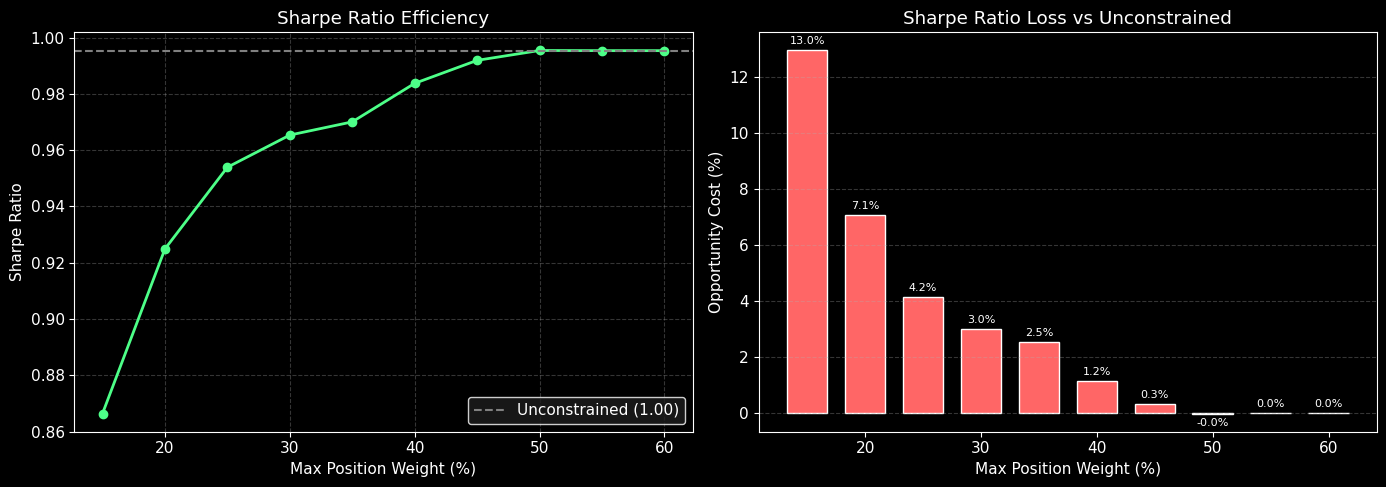

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(results['Max weight'], results['Sharpe'], color='#4dff88', marker='o', lw=2)
ax1.axhline(unconstraint_sharpe, ls='--', color='grey', label=f'Unconstrained ({unconstraint_sharpe:.2f})')
ax1.set(xlabel='Max Position Weight (%)', ylabel='Sharpe Ratio', title='Sharpe Ratio Efficiency')
ax1.grid(True, alpha=0.3, ls='--')
ax1.legend(facecolor='#1e1e1e', labelcolor='white')


bars = ax2.bar(results['Max weight'], results['Sharpe Cost (%)'], width=(results['Max weight'].iloc[1] - results['Max weight'].iloc[0])* 0.7, color='#ff6666', edgecolor='white')
ax2.set(xlabel='Max Position Weight (%)', ylabel='Opportunity Cost (%)', title='Sharpe Ratio Loss vs Unconstrained')
ax2.grid(True, alpha=0.3, ls='--', axis='y')
ax2.bar_label(bars, fmt='%.1f%%', padding=3, color='white', fontsize=8)

for ax in (ax1, ax2):
    ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

The Markowitz mean-variance model suffers from a well-known hypersensitivity to input estimation errors, acting as a "noise amplifier" that generates unstable and extreme portfolios. While imposing weight constraints addresses this issue by stabilizing allocations, it introduces an inevitable opportunity cost regarding theoretical in-sample efficiency, as it restricts the optimizer's room for maneuver.

The data clearly illustrate this trade-off: overly strict constraints (below 25%) stifle the model, penalizing the Sharpe Ratio by more than 7%, whereas beyond 50%, the curve flattens, rendering the limits superfluous. The optimal balance point (or "knee point") lies between 30% and 35%: at this level, the loss in Sharpe Ratio is minimal (less than 3%), yet maximum gains in portfolio stability and robustness are achieved.

--- 

## 8) Conclusions
While Markowitz's classical Mean-Variance framework remains a foundational benchmark in modern portfolio theory, its direct application to empirical data is severely hindered by high sensitivity to input estimation errors. Unconstrained optimization tends to act as an "error maximizer," producing unstable and highly concentrated allocations.

The findings of this study yield two key insights:

- Efficacy of Structural Constraints: Implementing explicit position caps (specifically within the 30%–35% range) proves to be the most decisive factor in dampening   allocation instability, yielding a far greater operational impact than purely statistical covariance regularization techniques.

- Justifiable Opportunity Cost: The restricted flexibility of the optimizer induces a marginal in-sample efficiency loss (a Sharpe Ratio reduction under 3%), which is heavily offset by out-of-sample benefits, including superior portfolio stability, reduced turnover, and realistic execution.

In summary, incorporating explicit weight constraints serves as the essential bridge between the theoretical framework of Markowitz optimization and the practical demands of real-world portfolio management.